In [1]:

#@title 1) Kurulum (~2-3 dk; derleme YOK, pytorch3d GEREKMEZ)
import os
if not os.path.exists('/content/MeshVTON'):
    !git clone https://github.com/SerhanTelatar/MeshVTON /content/MeshVTON
%cd /content/MeshVTON
!git pull

# Yalnız eksik paketler (torch/transformers/accelerate Colab'da hazır):
!pip -q install "diffusers>=0.34" "peft>=0.14" lpips einops sentencepiece trimesh smplx pyrender onnxruntime
# OSMesa için pyrender'ın yamalı PyOpenGL fork'u ŞART (pip PyOpenGL'i
# "No array-type handler" ctypes hatası veriyor):
!pip -q uninstall -y pyopengl PyOpenGL-accelerate > /dev/null 2>&1
!pip -q install "git+https://github.com/mmatl/pyopengl.git"
# 4D-Humans (HMR2 — gerçek poz + pred_cam kamerası; kamera kapısı bunsuz çalışmaz)
import importlib.util
if importlib.util.find_spec('hmr2') is None:
    !pip -q install "git+https://github.com/shubham-goel/4D-Humans.git"
# GL sistem kütüphaneleri (Colab imajında libGLU yok -> pyrender import hatası)
!apt-get -qq install -y libglu1-mesa libosmesa6 > /dev/null 2>&1
# EGL çalışıyorsa onu, yoksa OSMesa'yı (yazılımsal, her yerde çalışır) kullan:
import subprocess
_probe = subprocess.run(["python", "-c",
    'import os;os.environ["PYOPENGL_PLATFORM"]="egl";'
    'import pyrender;r=pyrender.OffscreenRenderer(16,16);r.delete();print("egl-ok")'],
    capture_output=True, text=True)
os.environ['PYOPENGL_PLATFORM'] = 'egl' if 'egl-ok' in _probe.stdout else 'osmesa'
print('GL platform:', os.environ['PYOPENGL_PLATFORM'])

# IDM-VTON yalnız KIŞI ön-işlemesi için (parsing onnx + openpose ckpt); densepose/detectron2 YOK
if not os.path.exists('/content/IDM-VTON'):
    !git clone -q https://github.com/yisol/IDM-VTON /content/IDM-VTON
# Ön-işleme model dosyaları: wget DEĞİL hf_hub_download (LFS'i doğru indirir; wget
# HF'ten HTML hata sayfası kaydedip INVALID_PROTOBUF'a yol açabiliyor)
import shutil
from huggingface_hub import hf_hub_download
for repo_path in ('humanparsing/parsing_atr.onnx',
                  'humanparsing/parsing_lip.onnx',
                  'openpose/ckpts/body_pose_model.pth'):
    local = f'/content/IDM-VTON/ckpt/{repo_path}'
    if not (os.path.exists(local) and os.path.getsize(local) > 1_000_000):
        os.makedirs(os.path.dirname(local), exist_ok=True)
        shutil.copy(hf_hub_download('yisol/IDM-VTON', repo_path), local)
    assert os.path.getsize(local) > 1_000_000, f'bozuk indirme: {local}'

# FLUX.1 dev gated: Colab Secrets'a HF_TOKEN ekleyin (soldaki anahtar simgesi, Notebook access açık)
from google.colab import userdata
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
print('Kurulum OK')

Cloning into '/content/MeshVTON'...
remote: Enumerating objects: 1094, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 1094 (delta 19), reused 49 (delta 18), pack-reused 1034 (from 1)
Receiving objects: 100% (1094/1094), 18.43 MiB | 22.33 MiB/s, done.
Resolving deltas: 100% (676/676), done.
/content/MeshVTON
Already up to date.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 85.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.5/745.5 kB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 123.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 72.7 MB/s eta 0:00:00
  Preparing m

humanparsing/parsing_atr.onnx: reconstructing file:   0%|          |  0.00B /  267MB            

humanparsing/parsing_atr.onnx: downloading bytes:           |  0.00B            

humanparsing/parsing_lip.onnx: reconstructing file:   0%|          |  0.00B /  267MB            

humanparsing/parsing_lip.onnx: downloading bytes:           |  0.00B            

openpose/ckpts/body_pose_model.pth: reconstructing file:   0%|          |  0.00B /  209MB            

openpose/ckpts/body_pose_model.pth: downloading bytes:           |  0.00B            

Kurulum OK


In [2]:
#@title 2) Veri — Drive/MeshVTON düzenine göre (images.zip, garments_3d.zip, smplx/, smplx_params.zip)
import os, sys
sys.path.insert(0, '/content/MeshVTON/v2')
from google.colab import drive
drive.mount('/content/drive')
D = '/content/drive/MyDrive/MeshVTON'

# zip'lerin İÇİNDE üst klasör var (images/, garments_3d/) -> bir üst hedefe aç:
!mkdir -p /content/MeshVTON/data/raw
!unzip -q -n $D/images.zip      -d /content/MeshVTON/data/raw    # -> data/raw/images/
!unzip -q -n $D/garments_3d.zip -d /content/MeshVTON/data        # -> data/garments_3d/

# SMPL-X modeli (Drive: MeshVTON/smplx/SMPLX_NEUTRAL.*) — 'checkpoints' klasörünü BİZ oluşturuyoruz,
# Drive'da olması gerekmiyor:
!mkdir -p /content/MeshVTON/checkpoints/pretrained/smplx
!cp $D/smplx/SMPLX_NEUTRAL.* /content/MeshVTON/checkpoints/pretrained/smplx/
os.environ['SMPLX_MODEL_DIR'] = '/content/MeshVTON/checkpoints/pretrained/smplx'

# Poz bankası: v1'in kişi başına SMPL-X tahminleri (sentetik veri gerçek pozlarla üretilsin)
!unzip -q -n $D/smplx_params.zip -d /content/MeshVTON/data/smplx_params

# HMR2 ağırlıkları (bir kez ~3.5GB) + SMPL neutral pkl (Drive: MeshVTON/smpl/)
import glob, shutil
from meshvton2.conditioning.body import _patch_torch_load_weights_only
import torch as _torch; _patch_torch_load_weights_only(_torch)
from hmr2.models import download_models
from hmr2.configs import CACHE_DIR_4DHUMANS
download_models(CACHE_DIR_4DHUMANS)
smpl_dir = f"{CACHE_DIR_4DHUMANS}/data/smpl"; os.makedirs(smpl_dir, exist_ok=True)
cands = glob.glob(f'{D}/smpl/*neutral*lbs*.pkl') + glob.glob(f'{D}/smpl/SMPL_NEUTRAL.pkl')
assert cands, "SMPL neutral pkl yok -> Drive/MeshVTON/smpl/ (smplify.is.tue.mpg.de)"
shutil.copy(cands[0], f"{smpl_dir}/SMPL_NEUTRAL.pkl")
print('HMR2 + SMPL hazır')

# doğrulama
!ls /content/MeshVTON/data/raw/images | head -3
!find /content/MeshVTON/data/garments_3d -name "*.obj" | wc -l
!ls /content/MeshVTON/checkpoints/pretrained/smplx
!ls /content/MeshVTON/data/smplx_params | head -3

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)



Extracting file: hmr2_data.tar.gz
HMR2 + SMPL hazır
00000_00.jpg
00001_00.jpg
00002_00.jpg
1636
SMPLX_NEUTRAL.npz
00000_00.npz
00001_00.npz
00002_00.npz


In [3]:
"""

!rm -rf /content/drive/MyDrive/MeshVTON/v2_outputs/stage1        # ← ZORUNLU: bozuk checkpoint
!rm -rf /content/drive/MyDrive/MeshVTON/v2_outputs/eval_results  # eski/geçersiz raporlar
!rm -f  /content/drive/MyDrive/MeshVTON/v2_outputs/synth_data.zip # 2.7GB boşuna inmesin
!rm -rf /content/drive/MyDrive/MeshVTON/v2_outputs/synth_qa      # eski QA görselleri
!rm -rf /content/MeshVTON/v2/data/synth                          # taze duman üretimi için eski verileri sil

"""


'\n\n!rm -rf /content/drive/MyDrive/MeshVTON/v2_outputs/stage1        # ← ZORUNLU: bozuk checkpoint\n!rm -rf /content/drive/MyDrive/MeshVTON/v2_outputs/eval_results  # eski/geçersiz raporlar\n!rm -f  /content/drive/MyDrive/MeshVTON/v2_outputs/synth_data.zip # 2.7GB boşuna inmesin\n!rm -rf /content/drive/MyDrive/MeshVTON/v2_outputs/synth_qa      # eski QA görselleri\n!rm -rf /content/MeshVTON/v2/data/synth                          # taze duman üretimi için eski verileri sil\n\n'

In [4]:
!pip -q uninstall -y torchao
%cd /content/MeshVTON
!git pull

/content/MeshVTON
Already up to date.


In [5]:

#@title 3) TEK-KOŞU pipeline — Run all yeter; her aşama resume'ludur
NUM_SYNTH     = 2000   #@param {type:"integer"}   # tam üretim; duman için 5-50 kullanın
TRAIN_STEPS   = 1000  #@param {type:"integer"}
UNTIL         = "baseline" #@param ["check","camera","smoke","synth","baseline","train","eval"]

# Colab koparsa: runtime'ı yeniden başlat -> Run all -> kaldığı yerden devam eder
# (sentetik üretim örnek sayısını sayar, eğitim latest.pt'den resume eder).
# NOT: VITON-HD gerçek-foto yolu bilinçli olarak pipeline'da yok (KALICI texturesuz
# kuralına aykırı düşüyordu — appearance ref orada mesh yok, tek sinyal renkli foto).
!python v2/scripts/colab_pipeline.py \
    --idm-repo /content/IDM-VTON \
    --num $NUM_SYNTH --train-steps $TRAIN_STEPS \
    --until $UNTIL


== 1/7 ortam kontrolü
repo: 96bebe4 commit
GPU: NVIDIA A100-SXM4-80GB (85 GB)
bağımlılıklar tamam

== 2/7 kamera doğrulama kapısı (IoU >= 0.70)
$ python v2/scripts/build_golden_set.py --vitonhd-test /content/MeshVTON/data/raw/images --garments /content/MeshVTON/data/garments_3d
UYARI: --person-list verilmedi; eşit aralıklı otomatik seçim yapıldı.
Golden set poz çeşitliliği (yan/¾) ve VITON-dışı 2-3 foto için ELLE küratörlük ister:
  seçimi v2/configs/golden_persons.txt'e yazıp düzenleyin.
OK: 20 kişi × 5 giysi × 4 açı = 400 değerlendirme öğesi
Manifest: /content/MeshVTON/v2/data/golden/manifest.json (commit'lenir; görüntüler gitignored)
$ python v2/scripts/validate_camera.py --idm-repo /content/IDM-VTON --limit 5
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
L

In [6]:
#@title 3.4) Askı kalibrasyonu — giysi mesh'i neden yukarıda?
!python v2/scripts/calibrate_hang.py --idm-repo /content/IDM-VTON

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Lightning automatically upgraded your loaded checkpoint from v1.8.1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/4DHumans/logs/train/multiruns/hmr2/0/checkpoints/epoch=35-step=1000000.ckpt`
100% 1/1 [00:00<00:00,  2.63it/s]
100% 1/1 [00:00<00:00,  3.05it/s]
/usr/local/lib/python3.12/dist-packages/hmr2/utils/geometry.py:61: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp

In [7]:

#@title 3.6) Kamera doğrulama — TÜM 20 kişi (kapı sadece 5'inde koşmuştu)
!python v2/scripts/validate_camera.py --idm-repo /content/IDM-VTON

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Lightning automatically upgraded your loaded checkpoint from v1.8.1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/4DHumans/logs/train/multiruns/hmr2/0/checkpoints/epoch=35-step=1000000.ckpt`
100% 1/1 [00:00<00:00,  1.56it/s]
100% 1/1 [00:00<00:00,  1.73it/s]
/usr/local/lib/python3.12/dist-packages/hmr2/utils/geometry.py:61: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp

In [8]:
import pathlib
src = pathlib.Path('/content/drive/MyDrive/MeshVTON/v2_outputs/eval_results')
dst = pathlib.Path('/content/MeshVTON/v2/eval_results')
if src.exists():
    !cp -rn {src} /content/MeshVTON/v2/
    print("geri yüklendi:", sum(1 for _ in dst.rglob('*.png')), "PNG")
else:
    print("Drive'da eval_results yok — atlandı")

geri yüklendi: 626 PNG


In [9]:
#@title 3.7) Eğitilmiş checkpoint'i 50 komboda değerlendir (~25 dk)
!python v2/scripts/eval_checkpoint.py \
    --checkpoint /content/drive/MyDrive/MeshVTON/v2_outputs/stage1/final.pt \
    --idm-repo /content/IDM-VTON --limit 50

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Lightning automatically upgraded your loaded checkpoint from v1.8.1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/4DHumans/logs/train/multiruns/hmr2/0/checkpoints/epoch=35-step=1000000.ckpt`
100% 1/1 [00:00<00:00,  2.70it/s]
100% 1/1 [00:00<00:00,  2.51it/s]
/usr/local/lib/python3.12/dist-packages/hmr2/utils/geometry.py:61: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp

In [10]:
#@title 3.8) Düzeltilmiş askıyla eval — uçtan uca işe yarıyor mu?
!python v2/scripts/eval_checkpoint.py \
    --checkpoint /content/drive/MyDrive/MeshVTON/v2_outputs/stage1/final.pt \
    --idm-repo /content/IDM-VTON --limit 10 --hang-pad -0.12 --tag-suffix _hp-012

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Lightning automatically upgraded your loaded checkpoint from v1.8.1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/4DHumans/logs/train/multiruns/hmr2/0/checkpoints/epoch=35-step=1000000.ckpt`
100% 1/1 [00:00<00:00,  2.77it/s]
100% 1/1 [00:00<00:00,  3.08it/s]
/usr/local/lib/python3.12/dist-packages/hmr2/utils/geometry.py:61: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp

In [11]:
#@title 3.85) Askı düzeltmesi geo_iou'yu yükseltti mi?
import json, statistics as st
from pathlib import Path
E = Path('/content/MeshVTON/v2/eval_results')
k = lambda r: (r['person'], r['garment'], r['angle'])
old = {k(r): r for r in json.load(open(E/'ckpt_control_on.json'))['rows']}
new = {k(r): r for r in json.load(open(E/'ckpt_control_on_hp-012.json'))['rows']}
sh = sorted(set(old) & set(new))
o = [old[i]['geo_iou'] for i in sh]; n = [new[i]['geo_iou'] for i in sh]
print(f"ortak {len(sh)} kombo — hang+0.06: {st.mean(o):.4f}   hang-0.12: {st.mean(n):.4f}   Δ={st.mean(n)-st.mean(o):+.4f}")

ortak 10 kombo — hang+0.06: 0.3163   hang-0.12: 0.3076   Δ=-0.0087


In [12]:
#@title 3.9) Mesh ayırt ediciliği — eski vs düzeltilmiş askı
!python v2/scripts/mesh_specificity.py --sets ckpt_control_on ckpt_control_on_hp-012 ckpt_control_off_hp-012

=== MESH AYIRT EDİCİLİĞİ (köşegen = doğru mesh, yüksek iyi) ===

ckpt_control_on
  doğru mesh  (köşegen)      = 0.3479  (n=50)
  yanlış mesh (köşegen dışı) = 0.3093  (n=200)
  AYIRT EDİCİLİK             = +0.0386  (+12.5%)

ckpt_control_on_hp-012
  doğru mesh  (köşegen)      = 0.3076  (n=10)
  yanlış mesh (köşegen dışı) = 0.2856  (n=40)
  AYIRT EDİCİLİK             = +0.0219  (+7.7%)

ckpt_control_off_hp-012
  doğru mesh  (köşegen)      = 0.2938  (n=10)
  yanlış mesh (köşegen dışı) = 0.2772  (n=40)
  AYIRT EDİCİLİK             = +0.0166  (+6.0%)

OKUMA: fark ~0 ise model hangi mesh verilirse verilsin aynı şeyi üretiyor —
       geo_iou'daki iyileşme mesh'e ÖZGÜ değil, dağılıma uyum demektir.
       Baseline setindeki farkı çıpa olarak kullanın (eğitimsiz model).


In [13]:
#@title 3.93) Mesh ayırt ediciliği — eski vs düzeltilmiş askı

!python v2/scripts/backfill_baseline_geo.py --idm-repo /content/IDM-VTON


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Lightning automatically upgraded your loaded checkpoint from v1.8.1 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/4DHumans/logs/train/multiruns/hmr2/0/checkpoints/epoch=35-step=1000000.ckpt`
100% 1/1 [00:00<00:00,  2.65it/s]
100% 1/1 [00:00<00:00,  3.08it/s]
/usr/local/lib/python3.12/dist-packages/hmr2/utils/geometry.py:61: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /pytorch/aten/src/ATen/native/Cross.cpp

In [14]:
#@title 3.95) Mesh ayırt ediciliği — çıktı verilen mesh'e mi özel?
!python v2/scripts/mesh_specificity.py --per-person

=== MESH AYIRT EDİCİLİĞİ (köşegen = doğru mesh, yüksek iyi) ===

phase1_fill_spatial
  doğru mesh  (köşegen)      = 0.2054  (n=100)
  yanlış mesh (köşegen dışı) = 0.2086  (n=400)
  AYIRT EDİCİLİK             = -0.0032  (-1.5%)
    00000_00     5 giysi: doğru=0.1680 yanlış=0.1772 fark=-0.0092
    00737_00     5 giysi: doğru=0.1430 yanlış=0.1475 fark=-0.0045
    01455_00     5 giysi: doğru=0.2156 yanlış=0.2227 fark=-0.0071
    02199_00     5 giysi: doğru=0.1715 yanlış=0.1717 fark=-0.0002
    02935_00     5 giysi: doğru=0.2006 yanlış=0.2030 fark=-0.0024
    03659_00     5 giysi: doğru=0.1887 yanlış=0.1815 fark=+0.0072
    04384_00     5 giysi: doğru=0.2142 yanlış=0.2181 fark=-0.0039
    05104_00     5 giysi: doğru=0.1422 yanlış=0.1551 fark=-0.0130
    05836_00     5 giysi: doğru=0.1578 yanlış=0.1571 fark=+0.0007
    06577_00     5 giysi: doğru=0.2928 yanlış=0.2937 fark=-0.0010
    07300_00     5 giysi: doğru=0.2412 yanlış=0.2431 fark=-0.0019
    08034_00     5 giysi: doğru=0.2230 yanlış=0

Now that the `CHECKPOINT` path has been successfully validated, you can proceed with your inference file using this path.

## ckpt_control_off

# Eval raporu
- Tahmin: 50/400 bulundu, eksik: 350

| metrik | genel | 0° | 90° | 180° | 270° |
|---|---|---|---|---|---|
| garment_delta_e | 10.8719 (n=50) | 10.8719 (n=50) | n/a | n/a | n/a |
| geo_iou | 0.3343 (n=50) | 0.3343 (n=50) | n/a | n/a | n/a |
| silhouette_iou | 0.2866 (n=50) | 0.2866 (n=50) | n/a | n/a | n/a |


## ckpt_control_off_hp-012

# Eval raporu
- Tahmin: 10/400 bulundu, eksik: 390

| metrik | genel | 0° | 90° | 180° | 270° |
|---|---|---|---|---|---|
| garment_delta_e | 10.9109 (n=10) | 10.9109 (n=10) | n/a | n/a | n/a |
| geo_iou | 0.2938 (n=10) | 0.2938 (n=10) | n/a | n/a | n/a |
| silhouette_iou | 0.2984 (n=10) | 0.2984 (n=10) | n/a | n/a | n/a |


## ckpt_control_on

# Eval raporu
- Tahmin: 50/400 bulundu, eksik: 350

| metrik | genel | 0° | 90° | 180° | 270° |
|---|---|---|---|---|---|
| garment_delta_e | 9.1154 (n=50) | 9.1154 (n=50) | n/a | n/a | n/a |
| geo_iou | 0.3479 (n=50) | 0.3479 (n=50) | n/a | n/a | n/a |
| silhouette_iou | 0.2866 (n=50) | 0.2866 (n=50) | n/a | n/a | n/a |


## ckpt_control_on_hp-012

# Eval raporu
- Tahmin: 10/400 bulundu, eksik: 390

| metrik | genel | 0° | 90° | 180° | 270° |
|---|---|---|---|---|---|
| garment_delta_e | 9.5314 (n=10) | 9.5314 (n=10) | n/a | n/a | n/a |
| geo_iou | 0.3076 (n=10) | 0.3076 (n=10) | n/a | n/a | n/a |
| silhouette_iou | 0.2984 (n=10) | 0.2984 (n=10) | n/a | n/a | n/a |


## phase1_fill_spatial

# Eval raporu
- Tahmin: 100/400 bulundu, eksik: 300

| metrik | genel | 0° | 90° | 180° | 270° |
|---|---|---|---|---|---|
| garment_delta_e | 14.6992 (n=100) | 14.6992 (n=100) | n/a | n/a | n/a |
| geo_iou | 0.2054 (n=100) | 0.2054 (n=100) | n/a | n/a | n/a |
| outside_mask_lpips | 0.0003 (n=100) | 0.0003 (n=100) | n/a | n/a | n/a |
| outside_mask_psnr | 56.4133 (n=100) | 56.4133 (n=100) | n/a | n/a | n/a |
| outside_mask_ssim | 0.9989 (n=100) | 0.9989 (n=100) | n/a | n/a | n/a |
| silhouette_iou | 0.2336 (n=100) | 0.2336 (n=100) | n/a | n/a | n/a |


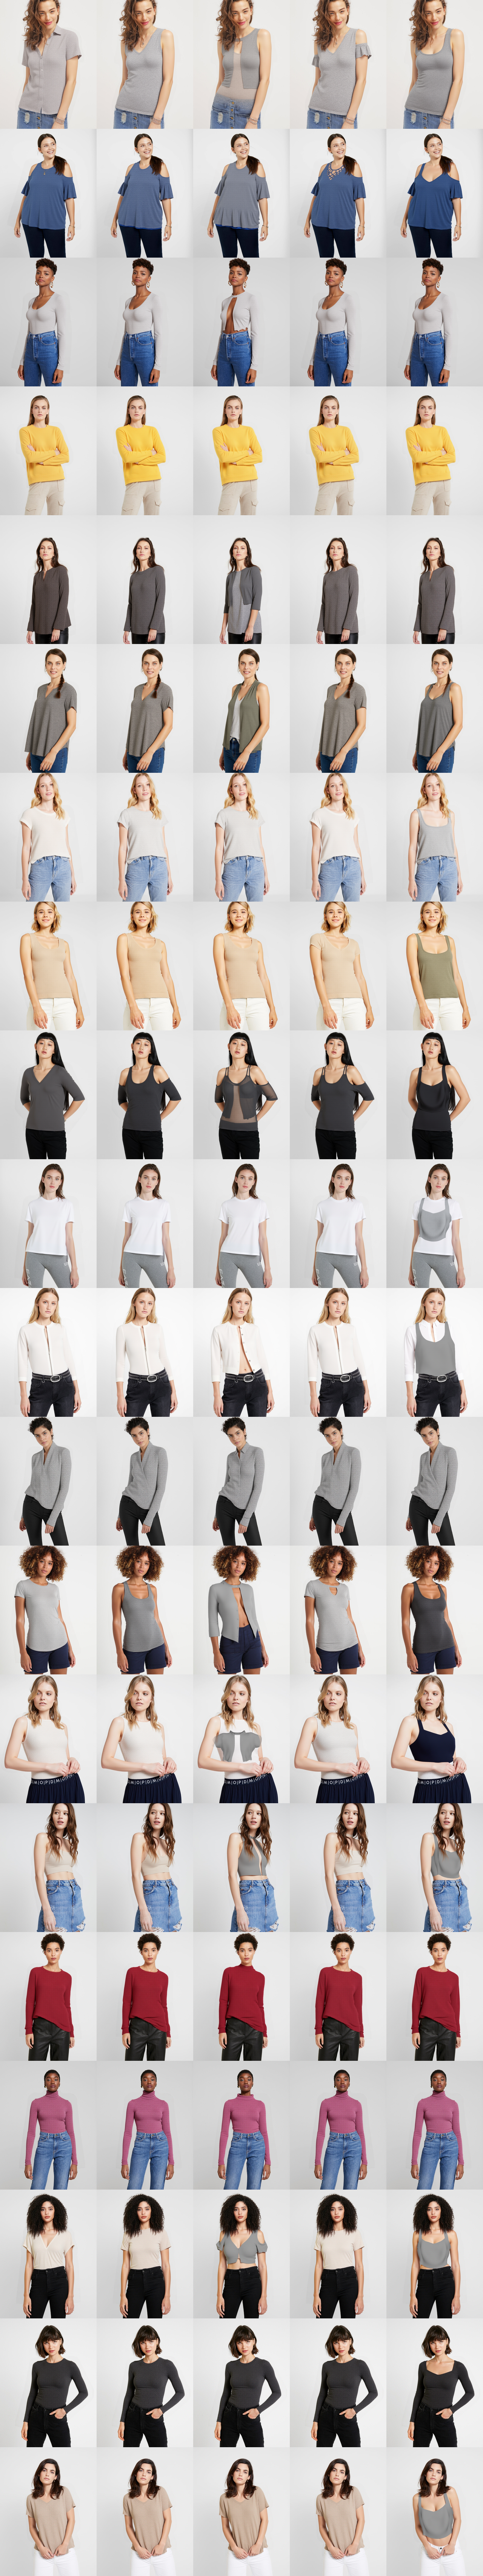

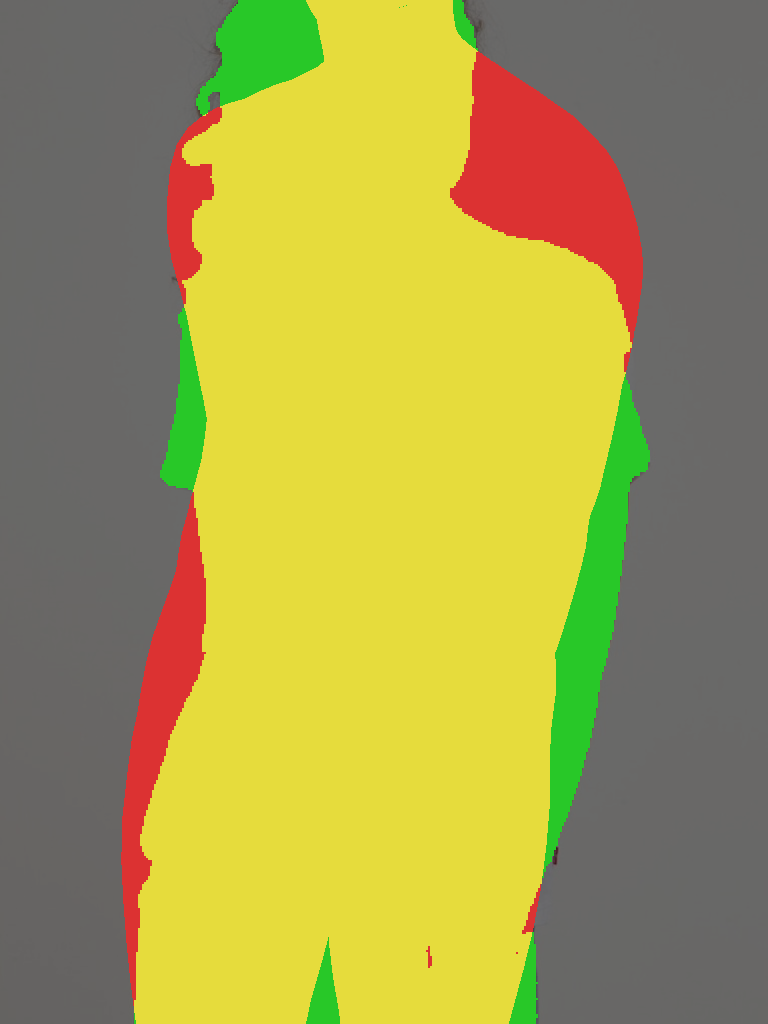

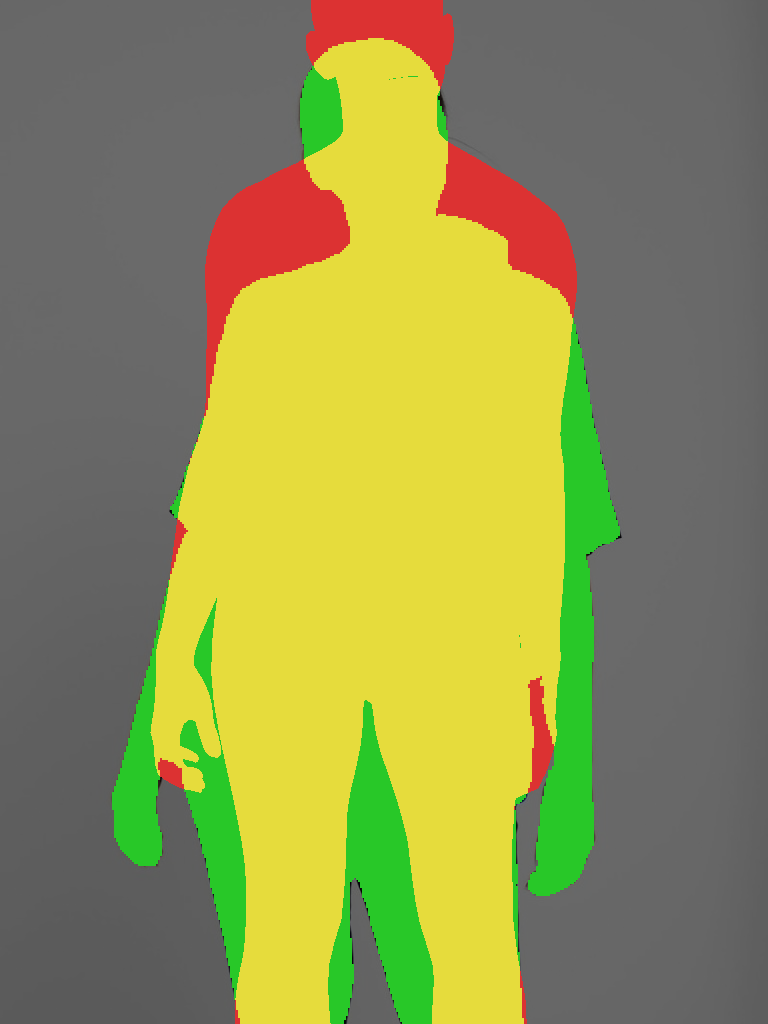

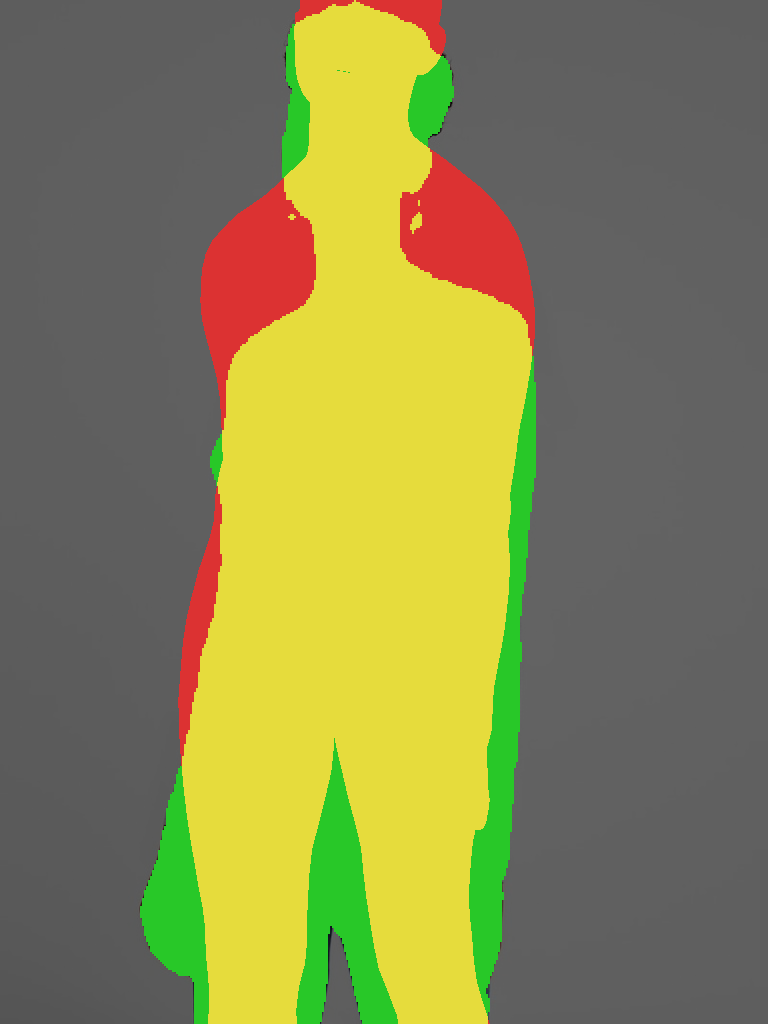

## Sentetik QA — 5 farklı giysi (sol: 0° ön, sağ: 180° arka)

**s000_000000**

**s000_000001**

**s000_000005**

**s000_000006**

**s000_000007**

In [15]:

#@title 4) Sonuçlar (Drive: MeshVTON/v2_outputs altında da var)
from IPython.display import Image as I, display, Markdown
import ipywidgets as widgets
from ipywidgets import HBox
import pathlib

for md in sorted(pathlib.Path("v2/eval_results").glob("*.md")):
    display(Markdown(f"## {md.stem}"), Markdown(md.read_text()))
for grid in sorted(pathlib.Path("v2/eval_results").glob("*_grid.png")):
    display(I(str(grid), width=900))

# kamera doğrulama overlay'leri
for f in sorted(pathlib.Path("v2/eval_results/camera_validation").glob("*.png"))[:3]:
    display(I(str(f), width=280))

# Sentetik QA: BİRDEN ÇOK giysi (tek örnek yanıltır — bozuk bir CLOTH3D mesh'i
# hattın tamamı sanılabiliyordu). Her satır bir giysi: önden ve arkadan.
qa = sorted(pathlib.Path("v2/eval_results/synth_qa").glob("s*/"))
display(Markdown(f"## Sentetik QA — {len(qa)} farklı giysi (sol: 0° ön, sağ: 180° arka)"))
for s in qa:
    row = [s / f"view_{v}" / "gt.png" for v in ("000", "180")]
    if all(f.exists() for f in row):
        display(Markdown(f"**{s.name}**"))
        display(HBox([widgets.Image(value=f.read_bytes(), width=260) for f in row]))

In [16]:
import json, statistics as st
from pathlib import Path
P = Path('/content/drive/MyDrive/MeshVTON/v2_outputs/eval_results')
b = json.load(open(P/'phase1_fill_spatial.json'))
c = json.load(open(P/'ckpt_control_on.json'))
k = lambda r: (r['person'], r['garment'], r['angle'])
B, C = {k(r): r for r in b['rows']}, {k(r): r for r in c['rows']}
shared = sorted(B.keys() & C.keys())
print(f"ortak kombo: {len(shared)}\n")
for m in sorted({x for r in list(B.values())+list(C.values()) for x in r} - {'person','garment','angle'}):
    bv = [B[i][m] for i in shared if B[i].get(m) is not None]
    cv = [C[i][m] for i in shared if C[i].get(m) is not None]
    if len(bv) == len(cv) == len(shared):
        print(f"{m:28s} baseline={st.mean(bv):8.4f}  ckpt={st.mean(cv):8.4f}  Δ={st.mean(cv)-st.mean(bv):+8.4f}")


ortak kombo: 10

garment_delta_e              baseline= 11.0599  ckpt=  9.6346  Δ= -1.4253


In [17]:
import numpy as np
from pathlib import Path
from PIL import Image
from skimage.color import rgb2lab
E = Path('/content/drive/MyDrive/MeshVTON/v2_outputs/eval_results')
def chroma(d):
    out = []
    for p in sorted(Path(d).glob('*.png')):
        if len(p.name.split('.')) != 2: continue
        m = Path(f"{p.with_suffix('')}.mask.png")
        if not m.exists(): continue
        img = np.asarray(Image.open(p).convert('RGB'))
        mk = np.asarray(Image.open(m).convert('L').resize(img.shape[1::-1], Image.NEAREST)) > 127
        if mk.any():
            lab = rgb2lab(img/255.0)[mk]
            out.append(float(np.hypot(lab[:,1], lab[:,2]).mean()))
    return np.mean(out), len(out)
for tag, d in [('baseline', E/'phase1_fill_spatial/preds'), ('ckpt', E/'ckpt_control_on/preds')]:
    c, n = chroma(d); print(f"{tag:9s} ortalama chroma = {c:6.2f}  (n={n})")


baseline  ortalama chroma =  12.55  (n=100)
ckpt      ortalama chroma =   1.79  (n=10)
